In [1]:
print("Hello World")

Hello World


In [2]:
import geopandas as gpd
from pystac_client import Client
import planetary_computer as pc
import odc.stac

catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=pc.sign_inplace)
alberta_bbox = [-113.0, 49.5, -112.0, 50.0]

print("📡 Querying STAC API for Sentinel-2 satellite tiles over Alberta...")
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=alberta_bbox,
    datetime="2025-07-10/2025-07-15",
    query={"eo:cloud_cover": {"lt": 20}}
)
items = list(search.item_collection())

if len(items) > 0:
    print(f"✅ SUCCESS! Engine is live. Found {len(items)} crystal-clear satellite tiles.")
else:
    print("❌ API connected, but no tiles matched filters.")

📡 Querying STAC API for Sentinel-2 satellite tiles over Alberta...
✅ SUCCESS! Engine is live. Found 10 crystal-clear satellite tiles.


In [3]:
import sys
import os
import pandas as pd
import xarray as xr
from geocube.api.core import make_geocube

sys.path.append(os.path.abspath("../"))
from src.data_loader import get_alberta_fields
from src.satellite_streamer import stream_satellite_cube

fields_gdf = get_alberta_fields()

ds = stream_satellite_cube(fields_gdf, start_date="2025-07-01", end_date="2025-07-31")

# Calculate NDVI so we have a metric to measure per field
ds["ndvi"] = (ds["B08"] - ds["B04"]) / (ds["B08"] + ds["B04"])


Successfully initialized spatial box layer (from collab).


c:\ProgramData\miniforge3\envs\crop-engine\Lib\site-packages\pystac_client\item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


In [21]:

# 1. Create a copy of your GeoDataFrame to avoid changing the original data
fields_numeric = fields_gdf.copy()

# 2. Convert your text IDs into unique integers (categorical encoding)
# This creates a mapping: 'lethbridge_block_01' becomes 1, etc.
fields_numeric['field_id_int'] = range(1, len(fields_numeric) + 1)

# Create a lookup dictionary so you can map the integers back to text names later
id_lookup = dict(zip(fields_numeric['field_id_int'], fields_numeric['field_group_id']))
print("ID Mapping Lookup Table:", id_lookup)

# 3. Now burn the INTEGERS into the raster cube instead of the strings
field_mask = make_geocube(
    vector_data=fields_numeric,
    measurements=["field_id_int"],  # Use the new integer column!
    like=ds
)


ID Mapping Lookup Table: {1: 'lethbridge_block_01'}


In [23]:
import numpy as np
import pandas as pd

# 1. Pull the 2D pixel grid out from geocube, fill backgrounds with 0, and match types
# This gives us a raw, predictable 2D NumPy array matrix
zone_mask_matrix = field_mask["field_id_int"].fillna(0).astype(np.int32).values

# 2. Extract our unique field IDs (ignoring the 0 background)
unique_zones = [z for z in np.unique(zone_mask_matrix) if z != 0]

zonal_results = []

print(f"Calculating zonal stats for zones: {unique_zones}...")

# 3. Iterate over each time step cleanly
for time_step in ds.time:
    # .compute() forces Xarray/Dask to load just this single timestamp snapshot into memory
    # as a raw 2D NumPy matrix, dodging all Dask and coordinate alignment errors
    ndvi_snapshot = ds.sel(time=time_step).ndvi.compute().values
    
    # 4. Use pure NumPy boolean masking to find the averages
    for zone_id in unique_zones:
        # Create a boolean array where pixels equal our specific field ID
        pixel_selector = (zone_mask_matrix == zone_id)
        
        # Extract those matching pixels out of our NDVI image snapshot
        zone_pixels = ndvi_snapshot[pixel_selector]
        
        # Calculate the mean, filtering out any random NaNs safely
        zone_mean = np.nanmean(zone_pixels) if len(zone_pixels) > 0 else np.nan
        
        # Append our row structure
        zonal_results.append({
            "zone": zone_id,
            "mean": zone_mean,
            "date": time_step.values,
            "field_name": id_lookup.get(zone_id, f"Field_{zone_id}")
        })

# 5. Instantly build the final pandas data frame
field_timeseries_df = pd.DataFrame(zonal_results)

print("\n--- Success! Zonal Extraction Complete ---")
print(field_timeseries_df.head())

Calculating zonal stats for zones: [np.int32(1)]...

--- Success! Zonal Extraction Complete ---
   zone      mean                    date           field_name
0     1  0.721817 2025-07-01 18:29:41.025  lethbridge_block_01
1     1  0.728082 2025-07-11 18:29:41.025  lethbridge_block_01
2     1  0.382414 2025-07-29 18:39:19.024  lethbridge_block_01
3     1  0.307564 2025-07-31 18:29:41.025  lethbridge_block_01


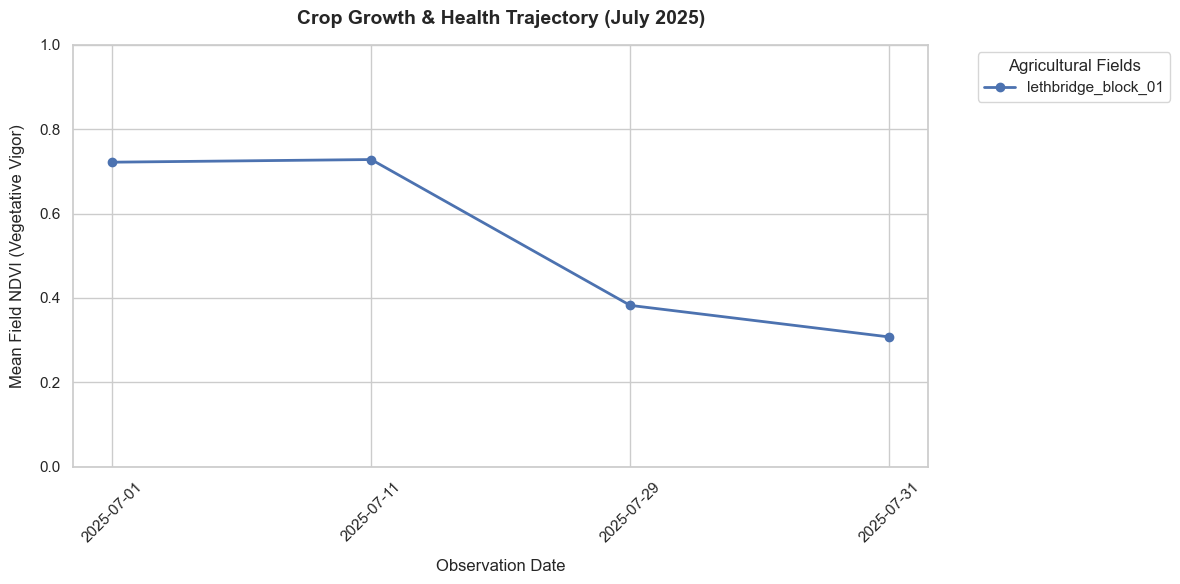

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Pivot the data frame so rows are dates, columns are your field names, and values are the mean NDVI
# This is the exact format needed to plot multiple lines effortlessly
plot_df = field_timeseries_df.pivot(index="date", columns="field_name", values="mean")

# Clean up the date index formatting for a nicer x-axis
plot_df.index = pd.to_datetime(plot_df.index).strftime('%Y-%m-%d')

# Plot every field as an individual line
for column in plot_df.columns:
    plt.plot(plot_df.index, plot_df[column], marker='o', linewidth=2, label=column)

# Style the graph
plt.title("Crop Growth & Health Trajectory (July 2025)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Observation Date", fontsize=12, labelpad=10)
plt.ylabel("Mean Field NDVI (Vegetative Vigor)", fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.ylim(0, 1.0) # NDVI naturally ranges from -1 to 1, but living crops sit between 0 and 1
plt.legend(title="Agricultural Fields", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the payoff!
plt.show()